#### 1. Configuração Inicial e Hardware
Importação das bibliotecas base e recarga automática dos módulos locais (`config` e `detectors`). Deteção do hardware disponível (CPU ou GPU/CUDA) para execução otimizada no PyTorch.

In [16]:
import importlib
import cv2
import torch
import matplotlib.pyplot as plt

import src.config as cfg
import src.detectors as detectors
import src.descriptors as descriptors

importlib.reload(cfg)
importlib.reload(detectors)
importlib.reload(descriptors)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch a usar: {device.upper()}")
if device == "cuda":
    print(f"Placa Gráfica: {torch.cuda.get_device_name(0)}")

PyTorch a usar: CPU


c:\Users\Beatriz\Desktop\Universidade\Mestrado\2Ano\Git\master-projects\artificial-intelligence-for-computer-vision\src\descriptors.py:4: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if detector_name is 'BRIEF_LIB':
c:\Users\Beatriz\Desktop\Universidade\Mestrado\2Ano\Git\master-projects\artificial-intelligence-for-computer-vision\src\descriptors.py:6: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif detector_name is 'SELF_BRIEF':
c:\Users\Beatriz\Desktop\Universidade\Mestrado\2Ano\Git\master-projects\artificial-intelligence-for-computer-vision\src\descriptors.py:8: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif detector_name is 'BRISK':
c:\Users\Beatriz\Desktop\Universidade\Mestrado\2Ano\Git\master-projects\artificial-intelligence-for-computer-vision\src\descriptors.py:10: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif detector_name is 'FREAK':


#### Etapa 2: Carregamento de Imagem e Deteção de Keypoints
Leitura de uma imagem de teste do dataset (ex: GRAF) e aplicação do detetor instanciado (SIFT). Os *keypoints* encontrados são desenhados sobre a imagem original para validação visual da distribuição e densidade dos pontos de interesse.

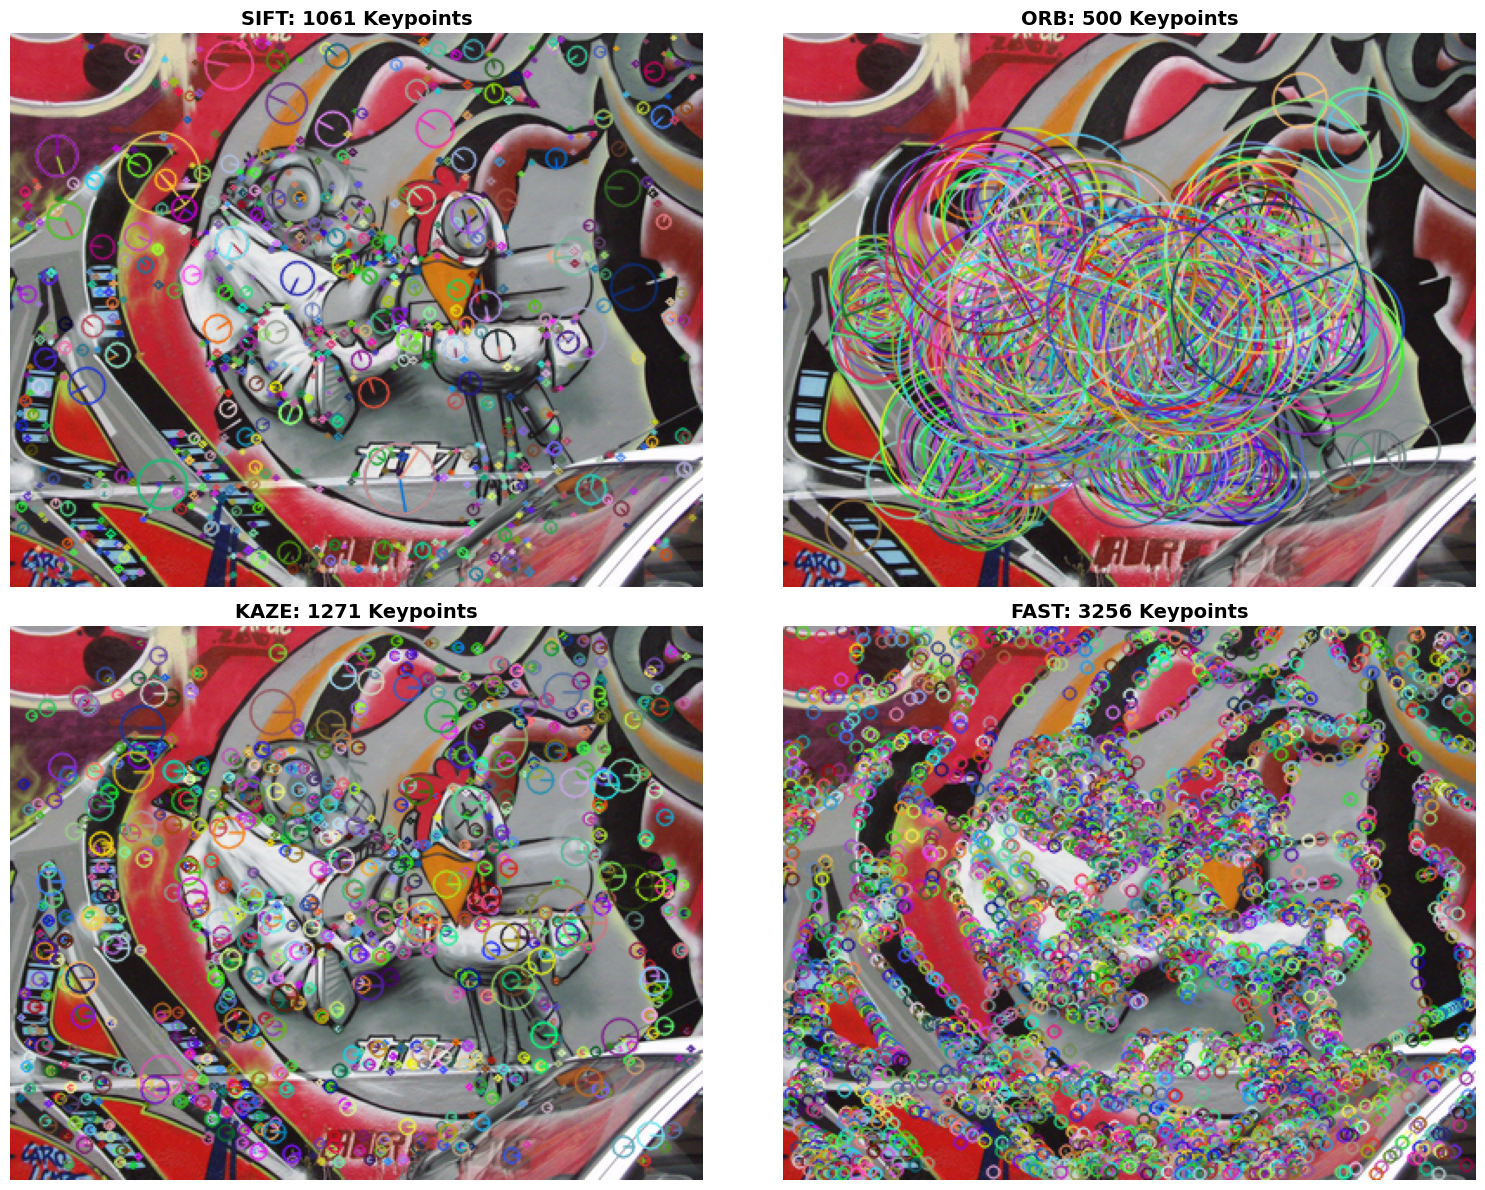

In [17]:
# 1. Carregar imagem de teste
img_path = cfg.DATA_DIR / "graf" / "img1.ppm"
img = cv2.imread(str(img_path))
if img is None:
    raise FileNotFoundError(f"Imagem não encontrada em {img_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
lista_detetores = ['SIFT', 'ORB', 'KAZE', 'FAST']

# 2. Configurar o layout dos subplots (2 linhas x 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 3. Iterar sobre cada detetor e desenhar os resultados
for ax, name in zip(axes, lista_detetores):
    det = detectors.get_detector(name)
    
    # Agora que o código está modular, recebemos a lista de pontos diretamente!
    kps = detectors.detect_keypoints(img, det)
        
    img_kp = cv2.drawKeypoints(
        img_rgb, kps, None, 
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    
    ax.imshow(img_kp)
    ax.set_title(f"{name}: {len(kps)} Keypoints", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
# compute the descriptors with BRIEF
det = detectors.get_detector('SIFT')
    
# Agora que o código está modular, recebemos a lista de pontos diretamente!
kps = detectors.detect_keypoints(img, det)
    
img_kp = cv2.drawKeypoints(
    img_rgb, kps, None, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

ax.imshow(img_kp)
ax.set_title(f"{name}: {len(kps)} Keypoints", fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

brief = descriptors.create_descriptor('BRIEF_LIB')
kps, des = descriptors.compute_descriptor(brief, img_rgb, kps)
print( des.shape )

<Figure size 640x480 with 0 Axes>

(783, 32)
